In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import os


In [2]:
# path_to_data = 'C:/Users/gabriel.battcock/OneDrive - World Food Programme/General - MIMI Project/Countries/Sri Lanka/data/'
path_to_data = '/Users/gabrielbattcock/Library/CloudStorage/OneDrive-WorldFoodProgramme/General - MIMI Project/Countries/Sri Lanka/data/'

In [3]:
food_security = pd.read_excel(path_to_data + "food_security_survey_2024/data-fs-sp_final-v2.xlsx")

In [4]:
path_to_hies =  "HIES_2019/HIES_2019/"
animal = pd.read_csv(path_to_data +path_to_hies+"SECTION_9_2_OWNED_LIVESTOCKS.csv")
income =  pd.read_csv(path_to_data +path_to_hies+"HH_expenditure_hh_Income.csv")

In [5]:
# makes hhid 
def make_hhid(df):
    # Ensure all parts are strings and handle missing values
    df['hhid'] = (
        df['psu'].astype(str).str.strip() +
        df['snumber'].astype(str).str.strip() +
        df['hhno'].astype(str).str.strip()
    ).astype(int)

make_hhid(animal)
make_hhid(income)

In [6]:
animal

,district,sector,month,psu,snumber,hhno,nhh,result,s9_cattle_buffaloes,cows_count,goats_sheeps,goat_count,pigs,pigs_count,chickens,chicken_count,other_animals,other_count,hhid
0,11,1,1,111088,1,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108811
1,11,1,1,111088,3,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108831
2,11,1,1,111088,5,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108851
3,11,1,1,111088,6,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108861
4,11,1,1,111088,7,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,11108871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19906,92,3,12,192085,6,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208561
19907,92,3,12,192085,7,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208571
19908,92,3,12,192085,8,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208581
19909,92,3,12,192085,9,1,1,1,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,19208591


In [7]:
# 2019 data
def get_asw_animal_2019(df):
    df['asw_animal'] = (
        ((df['s9_cattle_buffaloes'] == 1) & (df['cows_count'] >= 5)) |
        ((df['goats_sheeps']== 1) & (df['goat_count']>=20)) |
        ((df['pigs']==1) & (df['pigs_count']>=10)) |
        ((df['chickens']) & (df['chicken_count']>=50))

    ).astype(int)

    df = df[['hhid','asw_animal']]
    return df

animal_19 = get_asw_animal_2019(animal)


In [8]:
def get_asw_animal_2024(df):

    df['asw_animal'] = (
        (df['PMT_number_animals_cattle'] >=5) |
        (df['PMT_number_animals_pig'] >=10 ) |
        (df['PMT_number_animals_goat'] >=10) |
        (df['PMT_number_animals_chicken'] >=50)
    ).astype(int)
    df = df[['@_id','asw_animal']]
    return df
animal_24 = get_asw_animal_2024(food_security)

<positron-console-cell-8>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


(array([1.2748e+04, 1.8410e+03, 2.5300e+02, 7.6000e+01, 3.1000e+01,
        3.7000e+01, 2.0000e+01, 1.1000e+01, 1.1000e+01, 7.0000e+00,
        2.2000e+01, 9.0000e+00, 8.0000e+00, 2.0000e+00, 3.0000e+00,
        3.0000e+00, 4.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([1.50000000e+03, 5.30825333e+04, 1.04665067e+05, 1.56247600e+05,
        2.07830133e+05, 2.59412667e+05, 3.10995200e+05, 3.62577733e+05,
        4.14160267e+05, 4.65742800e+05, 5.17325333e+05, 5.68907867e+05,
        6.20490400e+05, 6.72072933e+05, 7.23655467e+05, 7.75238000e+05,
        8.26820533e+05, 8.7840

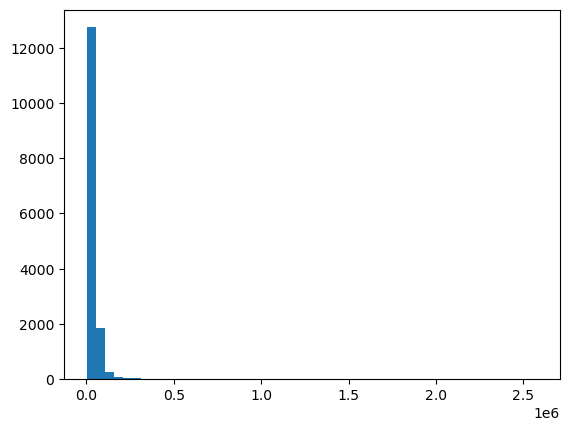

In [9]:

plt.hist(food_security['totalNFMonthly'], bins = 50)



In [10]:

print(food_security.columns.tolist())

['start', 'end', 'today', 'deviceid', 'TechnicalBasic_submoduleSvyDate', 'TechnicalBasic_submoduleSupvName', 'TechnicalBasic_submodulesupv_other', 'EnuName', 'enu_other', 'Province', 'Disitrict', 'DSDivison', 'GNDivison', 'OtherGNdivisonSpecifiy', 'sector', 'RESPConsent', 'resp_refusalwhy', 'resp_ref_other', 'EnuComments', 'resp_firstname', 'resp_lastname', 'RESPAge', 'RESPSex', 'RESPRelationHHH', 'RESPRelationHHH_oth', 'HHHAge', 'HHHSex', 'hh_education', 'hh_maritalstat', 'HHSize', 'HHSize01F', 'HHSize24F', 'HHSize511F', 'fem_hhmemHHSize1217F', 'fem_hhmemHHSize1859F', 'fem_hhmemHHSize59upF', 'male_hhmemHHSize01M', 'male_hhmemHHSize24M', 'male_hhmemHHSize511M', 'male_hhmemHHSize1217M', 'male_hhmemHHSize1859M', 'male_hhmemHHSize59upM', 'HHSize_calc', 'PMT_Education1', 'PMT_Education2', 'HHSizeRep', 'HHSizePlw', 'HHmem0_14', 'HHMem64above', 'HHmem1564', 'PMT_HHSizeCronDi', 'PMT_HHSizewhatcr', 'PMT_HHSizewhatcr1', 'PMT_HHSizewhatcr2', 'PMT_HHSizewhatcr3', 'PMT_HHSizewhatcr4', 'PMT_HHSizew

# Income

In [11]:
def get_asw_perexp_2024(df):

    df['TotalConsumption'] = (df['TotalFexpMonthly'] + df['totalNFMonthly'])/df['HHSize']

    df['asw_perexp_poor'] = (
        df['TotalConsumption']<16000
    ).astype(int)

    df = df[['@_id', 'asw_perexp_poor']]
    return df

poverty_24 = get_asw_perexp_2024(food_security)

<positron-console-cell-11>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<positron-console-cell-11>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [12]:
def get_food_expenditure_share(df):

    total_exp = df['TotalFexpMonthly'] + df['totalNFMonthly']

    df['food_exp_share'] = df['TotalFexpMonthly'] / total_exp.replace(0, np.nan)

    df = df[['@_id', 'food_exp_share']]
    return df

food_exp_24 = get_food_expenditure_share(food_security)
food_exp_24

<positron-console-cell-12>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


,@_id,food_exp_share
0,64979777,0.589178
1,64864373,0.642810
2,65572640,0.375487
3,65031840,0.543685
4,64977799,0.522711
...,...,...
15095,66449824,0.493480
15096,66449825,0.556831
15097,66449828,0.704062
15098,66449829,0.705674


In [13]:
poverty_24[poverty_24['asw_perexp_poor']==1]

,@_id,asw_perexp_poor
0,64979777,1
3,65031840,1
4,64977799,1
7,64978857,1
8,65560777,1
...,...,...
15092,66442323,1
15093,66442324,1
15096,66449825,1
15097,66449828,1


In [14]:
poverty_24

,@_id,asw_perexp_poor
0,64979777,1
1,64864373,0
2,65572640,0
3,65031840,1
4,64977799,1
...,...,...
15095,66449824,0
15096,66449825,1
15097,66449828,1
15098,66449829,1


In [15]:
def get_asw_perexp_2019(df):
    # change based on inflation
    df['asw_perexp_poor'] =(df['hhexppm']/df['hhsize']  < 8104).astype(int)

    df = df[['hhid','asw_perexp_poor']]
    return df

poverty19 = get_asw_perexp_2019(income)

In [16]:
income

,district,sector,psu,snumber,hhno,finalweight,hhsize,hhexppm,hhfoodexppm,hhincomepm,hhid,asw_perexp_poor
0,11,1,111088,1,1,392.442535,4,66041.531,32395.7150,130232.140,11108811,0
1,11,1,111088,3,1,392.442535,6,118624.340,42398.5700,139371.630,11108831,0
2,11,1,111088,5,1,392.442535,6,83343.508,44914.2850,84240.477,11108851,0
3,11,1,111088,6,1,392.442535,7,128843.020,61628.5700,115530.950,11108861,0
4,11,1,111088,7,1,392.442535,4,154795.020,55830.0000,198311.910,11108871,0
...,...,...,...,...,...,...,...,...,...,...,...,...
19906,92,3,192085,6,1,259.314922,5,72831.188,41948.5700,57434.285,19208561,0
19907,92,3,192085,7,1,259.314922,2,15257.096,9351.4287,14271.429,19208571,1
19908,92,3,192085,8,1,259.314922,6,39411.582,23065.7150,68222.859,19208581,1
19909,92,3,192085,9,1,259.314922,3,27236.381,16500.0000,31941.572,19208591,0


In [17]:
def get_food_expenditure_share_2019(df):

    df['food_exp_share'] = df['hhfoodexppm'] / df['hhexppm']

    df = df[['hhid', 'food_exp_share']]
    return df


food_share_19 = get_food_expenditure_share_2019(income)

In [18]:
# poverty19.to_csv('../../data/processed/features/asw_perexp_2019.csv')
# poverty_24.to_csv('../../data/processed/features/asw_perexp_2024.csv')
# animal_24.to_csv('../../data/processed/features/asw_animal_2024.csv')
# animal_19.to_csv('../../data/processed/features/asw_animal_2019.csv')
food_share_19.to_csv('../../data/processed/features/food_exp_share_2019.csv')
food_exp_24.to_csv('../../data/processed/features/food_exp_share_2024.csv')

Look at the features compared to mimi simple

In [19]:
poverty19[poverty19['asw_perexp_poor']==1]
# poverty19

,hhid,asw_perexp_poor
26,11104551,1
75,11109721,1
132,11100771,1
133,11100781,1
166,111009101,1
...,...,...
19888,19206711,1
19894,19204011,1
19903,19208531,1
19907,19208571,1


In [23]:
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-11-13.csv")
ml_targets

,iso3,survey,hhid,month,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar
0,LKA,lka_hies19,11100111,1,141.771251,203.900155,0.664669,10.511153,7.443397,0.594869
1,LKA,lka_hies19,11100121,1,156.913148,294.643247,2.095717,16.224352,12.205733,0.864046
2,LKA,lka_hies19,11100131,1,129.682588,157.911251,0.570306,15.480013,9.110019,0.636291
3,LKA,lka_hies19,11100141,1,68.646014,155.070328,1.249101,7.259847,4.729379,0.480061
4,LKA,lka_hies19,11100151,1,199.522686,204.118187,1.003891,10.476471,8.111925,0.667098
...,...,...,...,...,...,...,...,...,...,...
19906,LKA,lka_hies19,19208551,12,66.503481,169.805471,0.792777,9.284953,9.448862,0.566066
19907,LKA,lka_hies19,19208561,12,126.022109,202.143046,0.979918,12.717502,11.817528,0.680711
19908,LKA,lka_hies19,19208571,12,107.433567,108.421219,0.560491,8.051044,7.167088,0.455042
19909,LKA,lka_hies19,19208581,12,81.682584,150.781143,1.035865,9.860609,10.237976,0.589026


In [35]:
poverty_targets = ml_targets[['hhid', 'folate_mcg']].merge(food_share_19)
poverty_targets

,hhid,folate_mcg,food_exp_share
0,11100111,203.900155,0.344173
1,11100121,294.643247,0.387547
2,11100131,157.911251,0.346365
3,11100141,155.070328,0.302336
4,11100151,204.118187,0.394886
...,...,...,...
19906,19208551,169.805471,0.561126
19907,19208561,202.143046,0.575970
19908,19208571,108.421219,0.612923
19909,19208581,150.781143,0.585252


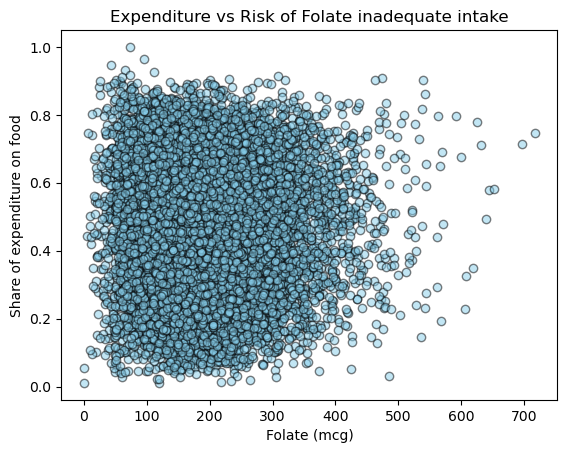

In [36]:

plt.scatter(poverty_targets[['folate_mcg']],poverty_targets['food_exp_share'],  color='skyblue', edgecolor='black', alpha = 0.5), 
plt.title('Expenditure vs Risk of Folate inadequate intake')
plt.xlabel('Folate (mcg)')
plt.ylabel('Share of expenditure on food')
plt.show()


In [42]:
animal_targets = ml_targets[['hhid', 'overall_mar']].merge(animal_new)
animal_targets

,hhid,overall_mar,asw_animal
0,11100111,0.594869,0
1,11100121,0.864046,0
2,11100131,0.636291,0
3,11100141,0.480061,0
4,11100151,0.667098,0
...,...,...,...
19906,19208551,0.566066,0
19907,19208561,0.680711,0
19908,19208571,0.455042,0
19909,19208581,0.589026,0


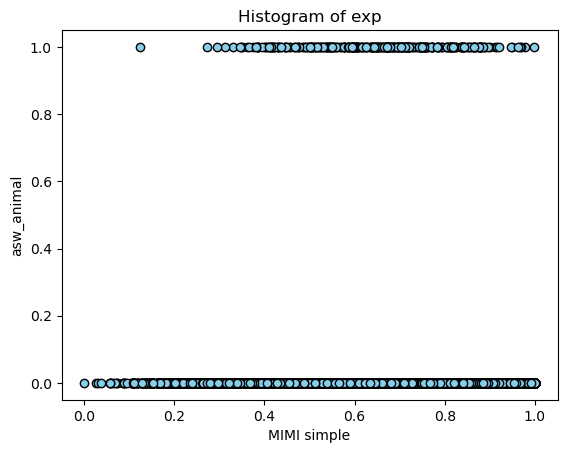

In [43]:
plt.scatter(animal_targets[['overall_mar']],animal_targets['asw_animal'],  color='skyblue', edgecolor='black')
plt.title('Histogram of exp')
plt.xlabel('MIMI simple')
plt.ylabel('asw_animal')
plt.show()